**The BM_25 Formula**

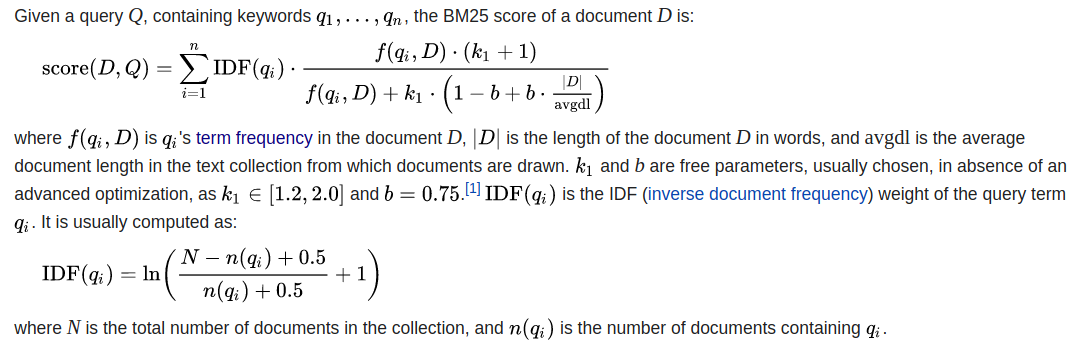

## BM_25 Class

In [1]:
import re
def remove_punctuation(text):
  pattern = re.compile(r'[^\w\s]')
  return pattern.sub(' ', text)

In [2]:
def get_unique_terms(corpus):
  unique_terms = set()
  for doc in corpus:
    for word in doc:
      unique_terms.add(word)
  return unique_terms


In [3]:
def get_avg_len(corpus):
  total_len = 0
  for doc in corpus:
    total_len += len(doc)
  return total_len/len(corpus)

In [4]:
import numpy as np

def get_idf(word, corpus):
  num_docs_with_word = 0
  for doc in corpus:
    words = set(doc)
    if word in words:
      num_docs_with_word += 1
  N = len(corpus)
  return np.log(1 + (N - num_docs_with_word + 0.5)/(num_docs_with_word + 0.5))

In [30]:
class BM25():
  def __init__(self, corpus, k1=1.2, b=0.3):
    self.corpus = corpus
    self.unique_terms = get_unique_terms(corpus)
    self.avglen = get_avg_len(corpus)
    self.k1 = k1
    self.b = b
    self.idf_scores = {}
    self.N = len(corpus)
    for term in self.unique_terms:
      self.idf_scores[term] = get_idf(term, corpus)
    self.doc_lengths = [
      len(doc)
      for doc in self.corpus
    ]
    self.tf_scores = []
    for i in range (self.N):
      self.tf_scores.append({})
      for words in self.corpus[i]:
        self.tf_scores[i][words] = (self.tf_scores[i][words] + 1) if self.tf_scores[i].get(words,0) else 1


  def get_tf(self, word, i, doc):
    count = self.tf_scores[i].get(word,0)
    return (count * (self.k1 + 1))/(count + self.k1 * (1 - self.b + self.b * self.doc_lengths[i]/self.avglen))


  def get_score(self, term, i, doc):
    return self.idf_scores[term] * self.get_tf(term, i, doc)

  def fit_transform(self, corpus, unique_terms):
    bm25_dict = []
    for doc in corpus:
      bm25_dict.append({})
    for i in range(self.N):
      words = set(corpus[i])
      for word in words:
        bm25_dict[i][word] = self.get_score(word, i, corpus[i])
    return bm25_dict

  def preprocess_query(self, query):
    query = remove_punctuation(query)
    return [w.lower() for w in query.split()]

  def get_total_score(self, i, query_words, bm25_dict):
    total_score = 0
    for word in query_words:
      if word in bm25_dict[i]:
        total_score += bm25_dict[i][word]
    return total_score

## Importing dataset and splitting it

In [6]:
import pandas as pd

df = pd.read_csv('/content/fake reviews dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text_'], df['label'], test_size=0.90, random_state=42)

In [8]:
X_train.head()

,text_
14908,"More garbage that's not anamorphic, it's anamo..."
9306,I love this keyboard! The different colors ava...
33724,"Great statue. The detail, colors and textures ..."
9867,Very Very fantastic camera. Have other full si...
27923,This is the second in the Roasted Love Cozy Se...


In [9]:
corpus = []
corpus_len = X_train.shape[0]
for i in range(corpus_len):
  corpus.append(X_train.iloc[i])

In [10]:
print(len(corpus))

4043


## Preprocessing corpus

In [11]:
for i, doc in enumerate(corpus):
  corpus[i] = remove_punctuation(doc)
  corpus[i] = corpus[i].lower().split()

In [12]:
import nltk
from nltk.corpus import stopwords

In [13]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
stop_words = set(stopwords.words('english'))

In [15]:
for doc in corpus:
  doc = [w for w in doc if not w in stop_words]

In [16]:
print(len(get_unique_terms(corpus)))

12968


## Creating parallel processing pipeline

In [17]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import heapq

In [19]:
def init_worker(bm25_instance, bm25_dict, y_train, x_test, corpus_len):
    global BM25
    global BM25_DICT
    global Y_TRAIN
    global X_TEST
    global CORPUS_LEN

    BM25 = bm25_instance
    BM25_DICT = bm25_dict
    Y_TRAIN = y_train
    X_TEST = x_test
    CORPUS_LEN = corpus_len

In [20]:
def process_chunk(start_idx, end_idx):

    predictions = []

    for idx in range(start_idx, end_idx):

        query = X_TEST.iloc[idx]
        processed_query = BM25.preprocess_query(query)

        scores = []

        for j in range(CORPUS_LEN):

            score = BM25.get_total_score(
                j,
                processed_query,
                BM25_DICT
            )

            scores.append((score, Y_TRAIN.iloc[j]))

        # Keep only top 10
        top10 = heapq.nlargest(10, scores)

        cg = 0
        or_ = 0

        for _, label in top10:
            if label == "CG":
                cg += 1
            else:
                or_ += 1

        predictions.append("CG" if cg > or_ else "OR")

    return predictions

In [21]:
def parallel_predict(
    bm25_instance,
    bm25_dict,
    X_test_check,
    y_train,
    corpus_len,
    num_workers=None,
):
    if num_workers is None:
        num_workers = multiprocessing.cpu_count()

    test_len = len(X_test_check)

    chunk_size = (test_len + num_workers - 1) // num_workers

    chunks = []

    for start in range(0, test_len, chunk_size):
        end = min(start + chunk_size, test_len)
        chunks.append((start, end))

    with ProcessPoolExecutor(
        max_workers=num_workers,
        initializer=init_worker,
        initargs=(
            bm25_instance,
            bm25_dict,
            y_train,
            X_test_check,
            corpus_len,
        ),
    ) as executor:

        futures = [
            executor.submit(process_chunk, start, end)
            for start, end in chunks
        ]

        y_pred = []

        for future in futures:
            y_pred.extend(future.result())

    return y_pred

## Creating BM25 instance

In [31]:
bm25_instance = BM25(corpus)

In [32]:
bm25_dict = bm25_instance.fit_transform(corpus, bm25_instance.unique_terms)

In [33]:
X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(df['text_'], df['label'], test_size=0.2, random_state=42)

In [34]:
test_len = X_test_check.shape[0]
print(test_len)

8087


## Making predictions and testing

In [35]:
y_pred = parallel_predict(
    bm25_instance,
    bm25_dict,
    X_test_check,
    y_train,
    corpus_len
)

In [36]:
print(y_pred)

['CG', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'CG', 'OR', 'OR', 'CG', 'CG', 'CG', 'CG', 'CG', 'OR', 'CG', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'OR', 'CG', 'OR', 'CG', 'CG', 'OR', 'CG', 'CG', 'OR', 'OR', 'CG', 'CG', 'OR', 'OR', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'CG', 'OR', 'CG', 'OR', 'OR', 'OR', 'OR', 'CG', 'CG', 'OR', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'OR', 'OR', 'OR', 'CG', 'OR', 'OR', 'OR', 'OR', 'CG', 'CG', 'CG', 'OR', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'OR', 'OR', 'OR', 'CG', 'OR', 'OR', 'CG', 'CG', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'OR', 'CG', 'CG', 'CG', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'CG', 'OR', 'CG', 'CG', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'CG', 'OR', 'OR', 'CG', 'OR', 'CG', 'CG', 'CG', 'OR', 'CG', 'OR', 'OR', 'OR', 'OR', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG', 'CG

In [37]:
from sklearn.metrics import f1_score

bm25_f1score = f1_score(y_test_check, y_pred, average='weighted')

In [38]:
print(bm25_f1score)

0.7566012805519962
